In [1]:
import os
import h5py
import pywt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from typing import List, Tuple
from scipy.stats import entropy
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from utils import process_file, label_lab, experiment_based_classification
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler

### Loading data

In [2]:
## Load stimuli
file = "../data/1D_ind_sin_stimuli_responses/MR-0644_flashes_sinusoidals_stimuli.h5"
ts = []
with h5py.File(file, "r") as f:
    for key in f.keys():
        ts.append(f[key]["data"][:])

## Load responses
path = '../data/1D_ind_sin_stimuli_responses/'
files = os.listdir(path)
file_names = [f for f in files if os.path.isfile(os.path.join(path, f))]
file_names = [f for f in file_names if "flashes_sinusoidals.h5" in f]

df = pd.DataFrame({"H":[i for i in range(42)]})
for file in file_names:
    means = process_file(path+file)
    df[file[:-23]] = means
df = df.T
df = df.drop(index=["H"])
df

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
MR-0644,"[-0.00024676729420533507, -0.00048507447407271...","[-0.0006610605025799696, 0.0002234065493280247...","[0.00047592569285939836, -0.000530924757832139...","[-5.3423853087005754e-05, -0.00146436379841268...","[-0.0010618159835306899, -0.003156465951578687...","[0.0001386449459426971, 0.00101067750455003, 0...","[-0.00037143290062919876, -0.00056081006722302...","[-0.00018394903511259546, -0.00076261754175243...","[-0.0004901587452150039, 0.0018185057693241467...","[-0.000865276124238152, -0.0001888439242439524...",...,"[-7.761409121477668e-05, -7.546264171878952e-0...","[-0.00042226766378839484, -0.00283181191946262...","[-0.0016318470793212085, -0.000882041280572446...","[2.877464240455598e-05, -0.0015462694741864259...","[0.0004820387368268984, -0.0001826679410438243...","[-0.0005555670988332548, -0.001132074288285714...","[0.0009005020811006079, 0.0012583347011023277,...","[0.0012417380482981234, 0.0029780678040637817,...","[0.00019115189299288073, 0.0019884939687984256...","[-2.5003134030896775e-06, -0.00051244175582721..."
MR-0645,"[-0.001146234522975336, -0.0023990090244361212...","[0.00040672187309684143, 0.0014145688235586659...","[-5.943996647582644e-05, -0.002808344134891233...","[2.7601688379250987e-05, 0.0008624702737431682...","[0.0006293816788908994, 0.0020958210803971836,...","[0.0003844487252471017, 0.001039504751568589, ...","[0.0002805362403708936, 0.0009476527460949506,...","[-0.000500124188629352, -0.0002437684763372750...","[-0.00013589464337917403, 0.001448603595199884...","[0.0014220731444664061, 0.0024950489834511492,...",...,"[-0.0010780921816669615, -0.003971623117227117...","[-0.0007284874528054402, -0.004151218345633532...","[0.0006726330235417125, 0.0002685823551740927,...","[-0.0009514022311126284, -0.003550269846939104...","[-0.000710307977694073, -0.0017517794513288256...","[0.0007122477221231744, -0.0012816145281151533...","[-0.0006007470161402746, 0.0003822014863958529...","[0.0005563269317171955, -0.0005884411652708502...","[-0.0002560205799583712, -0.000327758165181621...","[0.0025634895515709213, 0.0046689923796339825,..."
MR-0648,"[-0.0008756799065772364, -0.000190407038448596...","[-0.00044525770959157334, -0.00090734736236595...","[-0.0009605040476337299, -0.000969338086152490...","[0.0009972065827477125, 0.001259854559238781, ...","[0.0003810773434747262, -9.846598150194799e-06...","[-0.00032918597996784284, -0.00010969859517987...","[0.00044844808245280847, 0.0002541677526649027...","[-0.001581358193415284, 0.0006261790993631737,...","[-0.00043228397134817805, -0.00051274931169233...","[-0.0005529549745858818, 0.000662487170224476,...",...,"[0.00035397906583120993, 0.001397605418950568,...","[-0.0005732356541323691, 0.0007551968417835565...","[-0.0008816677353216328, -0.001323300987256707...","[0.0005628554330950336, 0.00023283087892509425...","[0.00017946405945166354, -0.000780860129594713...","[-0.0008033334950655833, -0.001778246460766482...","[0.0009459688190485966, 0.0015696985900978948,...","[0.0006260500768238199, 0.0001615885890063175,...","[0.0004031849719912496, -0.0011538865149443268...","[-0.0008257227453189434, 1.9591019594724974e-0..."
MR-0649,"[0.0006113718612664114, -0.0004099488682806194...","[-0.00036345613071687007, -0.00079381633266008...","[0.00041587625798359225, 0.0004339045196749006...","[-0.000470757498912155, -0.0004977080306818648...","[0.0005323030823376522, 0.0023796428582172186,...","[6.601965281790185e-05, -0.0002886537291881644...","[0.0010054606498580677, 0.0018139128710283172,...","[0.00047122926964059087, -4.760826866960795e-0...","[0.00011769274355226282, 0.0008426946795206849...","[0.001052400853975255, -0.0001039461058087415,...",...,"[-0.00012480129381858075, 0.000942934484990861...","[-8.775949351040706e-05, 0.0007341185689526748...","[-0.0009185183831878756, -0.003081486635313459...","[0.0009829865231020785, 0.001289716653828258, ...","[0.00024524121037949263, 6.701695370976096e-05..

In [3]:
## For ploting purposes we assign the corresponding labels and colors for mice
groups = {
    "5xFAD_3mF": ['MR-0644', 'MR-0645', 'MR-0648', 'MR-0649'],
    "5xFAD_3mM": ['MR-0661','MR-0663','MR-0667'],
    "5xFAD_6mF": ['MR-0659-t1', 'MR-0659-t2', 'MR-0676'],
    "5xFAD_6mM": ['MR-0657-t2', 'MR-0674', 'MR-0656'],
    "WT_3mF": ['MR-0677', 'MR-0678'],
    "WT_3mM": ['MR-0662', 'MR-0665', 'MR-0668', 'MR-0669'],
    "WT_6mF": ['MR-0679', 'MR-0680'],
    "WT_6mM": ['MR-0655', 'MR-0658', 'MR-0654-t1', 'MR-0654-t2', 'MR-0687-t1']
}

colors = {}
for key in groups.keys():
    for value in groups[key]:
        if "5xFAD_3m" in key:
            colors[value] = "r"
        elif "5xFAD_6m" in key:
            colors[value] = "b"
        elif "WT_3m" in key:
            colors[value] = "g"
        elif "WT_6m" in key:
            colors[value] = "m"
        else:
            colors[value] = "k"

for value in df.index:
    if value != "H":
        if value not in colors.keys():
            colors[value] = "k"

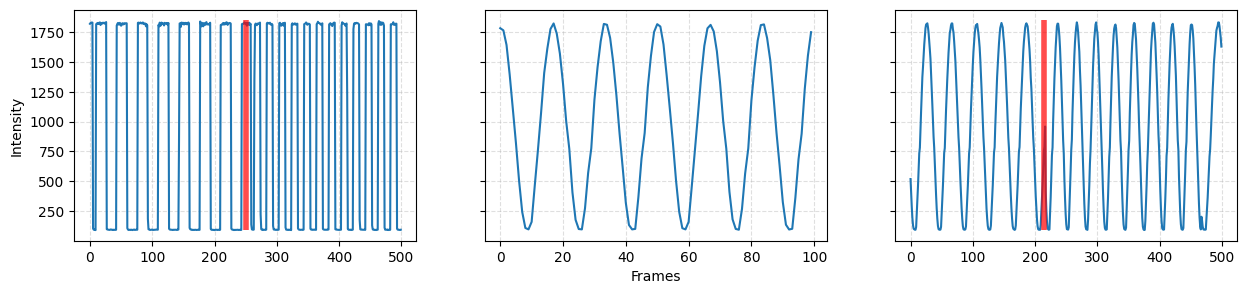

In [4]:
## few examples of the actual stimulus
fig, axs = plt.subplots(1,3,sharey=True,figsize=(15,3))
n1 = 500
n2 = 600
n3 = 800
axs[0].plot(ts[1][n1:n1+500])
axs[0].vlines(250,90,1850,alpha=0.7,color="r",linewidth=4)
axs[1].plot(ts[5][n2:n2+100])
axs[2].plot(ts[9][n3:n3+500])
axs[2].vlines(215,90,1850,alpha=0.7,color="r",linewidth=4)
axs[0].set_ylabel("Intensity")
axs[1].set_xlabel("Frames")
axs[0].grid(True,alpha=0.4,linestyle="--")
axs[1].grid(True,alpha=0.4,linestyle="--")
axs[2].grid(True,alpha=0.4,linestyle="--")
plt.show()

## wavelet analyses

In [5]:
wavelet_props = df.copy()
kl_stats = df.copy()
color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']
labels_sujetos = []
for ex in range(21):
    stimuli_profile = pywt.wavedec(ts[ex+1], wavelet='db2')
    stimuli_approx = stimuli_profile[0]
    stimuli_total_energy = np.sum(np.square(stimuli_approx))
    stimuli_details = [np.sum(np.square(stimuli_approx))]
    for level_dict in stimuli_profile[1:]:
        level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
        stimuli_total_energy += level_energy
        stimuli_details.append(level_energy)

    stimuli_proportions = [e / stimuli_total_energy for e in stimuli_details]

    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.abs(df.at[df.index[indice], ex])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            wavelet_props.at[df.index[indice], ex] = proportions
            kl_stats.at[df.index[indice], ex] = entropy(stimuli_proportions,proportions)
            if ex == 1:
                l = label_lab(df.index[indice],groups)
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')

entropy_stats = wavelet_props.copy()
for column in entropy_stats.columns:
    if column != "type":
        entropy_stats[column] =  wavelet_props[column].apply(entropy)

wavelet_props['type'] = labels_sujetos
entropy_stats['type'] = labels_sujetos
kl_stats['type'] = labels_sujetos

for column in entropy_stats.columns:
    if column != "type":
        wavelet_props[column] =  wavelet_props[column].apply(lambda x: x[3])

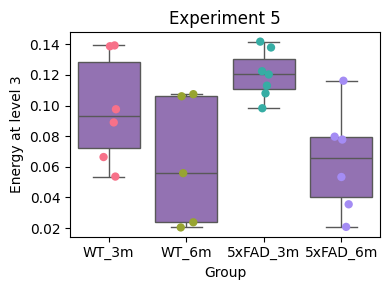

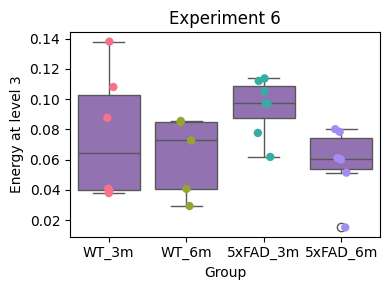

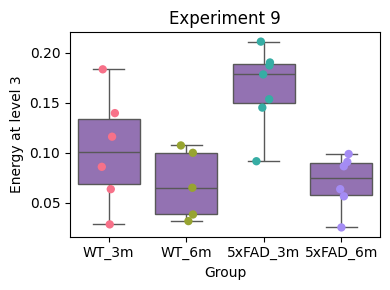

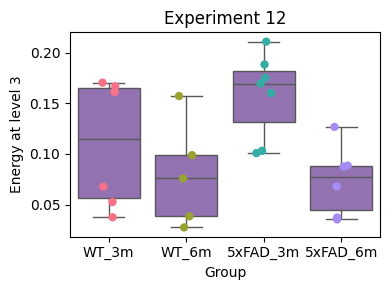

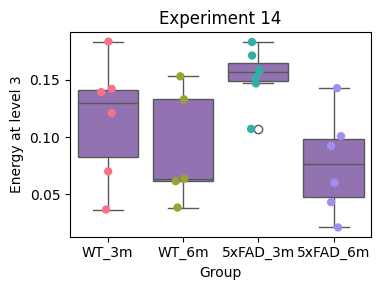

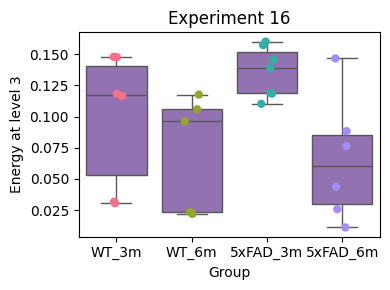

In [6]:
for stimuli in [5,6,9,12,14,16]:
    plt.figure(figsize=(4,3))
    sns.stripplot(data=wavelet_props[wavelet_props['type']!='no class'], x='type', y=stimuli, jitter=True, size=6, palette='husl',hue='type')
    sns.boxplot(data=wavelet_props[wavelet_props['type']!='no class'], x='type', y=stimuli)
    plt.xlabel("Group")
    plt.ylabel("Energy at level 3")
    plt.title(f'Experiment {stimuli}')
    plt.tight_layout()
    plt.show()

In [7]:
wavelet_props = wavelet_props[wavelet_props["type"] != "no class"]
print(wavelet_props['type'].value_counts())

type
5xFAD_3m    7
WT_3m       6
5xFAD_6m    6
WT_6m       5
Name: count, dtype: int64


In [ ]:
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(wavelet_props[i]).reshape(-1, 1), np.asarray(wavelet_props['type'].apply(age))) for i in range(21)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]

classifiers_age_energy = []
for dataset in datasets:
    n_ex, X, y = dataset
    
    loo = LeaveOneOut()
    y_true, y_pred = [], []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Grid search with inner CV
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        
        # Best pipeline from grid search
        best_clf = grid.best_estimator_
        # Predict
        prediction = best_clf.predict(X_test)
        
        y_true.append(y_test[0])
        y_pred.append(prediction[0])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 50.00%


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Lo

LOOCV Accuracy 1: 45.83%


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


...

c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Lo

LOOCV Accuracy 8: 66.67%
LOOCV Accuracy 9: 83.33%
LOOCV Accuracy 10: 58.33%
LOOCV Accuracy 11: 20.83%
LOOCV Accuracy 12: 70.83%


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 13: 58.33%
LOOCV Accuracy 14: 79.17%


KeyboardInterrupt: 

In [ ]:
experiment_based_classification(wavelet_props,condition)

LOOCV Accuracy 0: 25.00%
LOOCV Accuracy 1: 41.67%
LOOCV Accuracy 2: 50.00%
LOOCV Accuracy 3: 37.50%
LOOCV Accuracy 4: 41.67%
LOOCV Accuracy 5: 25.00%
LOOCV Accuracy 6: 79.17%
LOOCV Accuracy 7: 45.83%
LOOCV Accuracy 8: 41.67%
LOOCV Accuracy 9: 33.33%
LOOCV Accuracy 10: 41.67%
LOOCV Accuracy 11: 29.17%
LOOCV Accuracy 12: 33.33%
LOOCV Accuracy 13: 45.83%
LOOCV Accuracy 14: 54.17%
LOOCV Accuracy 15: 62.50%
LOOCV Accuracy 16: 25.00%
LOOCV Accuracy 17: 62.50%
LOOCV Accuracy 18: 41.67%
LOOCV Accuracy 19: 54.17%
LOOCV Accuracy 20: 45.83%


{'0': 0.25,
 '1': 0.4166666666666667,
 '2': 0.5,
 '3': 0.375,
 '4': 0.4166666666666667,
 '5': 0.25,
 '6': 0.7916666666666666,
 '7': 0.4583333333333333,
 '8': 0.4166666666666667,
 '9': 0.3333333333333333,
 '10': 0.4166666666666667,
 '11': 0.2916666666666667,
 '12': 0.3333333333333333,
 '13': 0.4583333333333333,
 '14': 0.5416666666666666,
 '15': 0.625,
 '16': 0.25,
 '17': 0.625,
 '18': 0.4166666666666667,
 '19': 0.5416666666666666,
 '20': 0.4583333333333333}

In [ ]:
experiment_based_classification(entropy_stats,condition)

LOOCV Accuracy 0: 57.69%
LOOCV Accuracy 1: 46.15%
LOOCV Accuracy 2: 26.92%
LOOCV Accuracy 3: 15.38%
LOOCV Accuracy 4: 53.85%
LOOCV Accuracy 5: 26.92%
LOOCV Accuracy 6: 65.38%
LOOCV Accuracy 7: 42.31%
LOOCV Accuracy 8: 57.69%
LOOCV Accuracy 9: 42.31%
LOOCV Accuracy 10: 23.08%
LOOCV Accuracy 11: 38.46%
LOOCV Accuracy 12: 19.23%
LOOCV Accuracy 13: 26.92%
LOOCV Accuracy 14: 46.15%
LOOCV Accuracy 15: 69.23%
LOOCV Accuracy 16: 7.69%
LOOCV Accuracy 17: 34.62%
LOOCV Accuracy 18: 53.85%
LOOCV Accuracy 19: 50.00%
LOOCV Accuracy 20: 34.62%


{'0': 0.5769230769230769,
 '1': 0.46153846153846156,
 '2': 0.2692307692307692,
 '3': 0.15384615384615385,
 '4': 0.5384615384615384,
 '5': 0.2692307692307692,
 '6': 0.6538461538461539,
 '7': 0.4230769230769231,
 '8': 0.5769230769230769,
 '9': 0.4230769230769231,
 '10': 0.23076923076923078,
 '11': 0.38461538461538464,
 '12': 0.19230769230769232,
 '13': 0.2692307692307692,
 '14': 0.46153846153846156,
 '15': 0.6923076923076923,
 '16': 0.07692307692307693,
 '17': 0.34615384615384615,
 '18': 0.5384615384615384,
 '19': 0.5,
 '20': 0.34615384615384615}

In [ ]:
experiment_based_classification(kl_stats,condition)

LOOCV Accuracy 0: 46.15%
LOOCV Accuracy 1: 42.31%
LOOCV Accuracy 2: 42.31%
LOOCV Accuracy 3: 46.15%
LOOCV Accuracy 4: 34.62%
LOOCV Accuracy 5: 50.00%
LOOCV Accuracy 6: 38.46%
LOOCV Accuracy 7: 65.38%
LOOCV Accuracy 8: 30.77%
LOOCV Accuracy 9: 0.00%
LOOCV Accuracy 10: 34.62%
LOOCV Accuracy 11: 19.23%
LOOCV Accuracy 12: 34.62%
LOOCV Accuracy 13: 23.08%
LOOCV Accuracy 14: 23.08%
LOOCV Accuracy 15: 15.38%
LOOCV Accuracy 16: 57.69%
LOOCV Accuracy 17: 11.54%
LOOCV Accuracy 18: 69.23%
LOOCV Accuracy 19: 42.31%
LOOCV Accuracy 20: 53.85%


{'0': 0.46153846153846156,
 '1': 0.4230769230769231,
 '2': 0.4230769230769231,
 '3': 0.46153846153846156,
 '4': 0.34615384615384615,
 '5': 0.5,
 '6': 0.38461538461538464,
 '7': 0.6538461538461539,
 '8': 0.3076923076923077,
 '9': 0.0,
 '10': 0.34615384615384615,
 '11': 0.19230769230769232,
 '12': 0.34615384615384615,
 '13': 0.23076923076923078,
 '14': 0.23076923076923078,
 '15': 0.15384615384615385,
 '16': 0.5769230769230769,
 '17': 0.11538461538461539,
 '18': 0.6923076923076923,
 '19': 0.4230769230769231,
 '20': 0.5384615384615384}

In [6]:
coactiv_stats = df.copy()

color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']#list(color_groups.keys())[:4]
labels_sujetos = []
for ex in range(21):
    #fig, ax = plt.subplots(1, figsize=(8, 5))
    
    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.multiply(ts[ex+1],np.abs(df.at[df.index[indice], ex])[:7500])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]  # start with approximation energy
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            coactiv_stats.at[df.index[indice], ex] = proportions
            if ex == 1:
                l = label_lab(df.index[indice],groups)
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')


coactiv_stats['type'] = labels_sujetos
coactiv_stats = coactiv_stats[coactiv_stats['type'] != 'no class']


for column in entropy_stats.columns:
    if column != "type":
        coactiv_stats[column] =  coactiv_stats[column].apply(lambda x: x[3])

#experiment_based_classification(coactiv_stats,age)

| Experimento | Wavelet | Entropy | KL Div | Co-Act |
|-------------|---------|---------|--------|--------|
| 0           | 50.00%  | 42.31%  | 42.31% | 58.33% |
| 1           | 45.83%  | 50.00%  | 34.62% | 62.50% |
| 2           | 54.17%  | <span style="background-color:#ccffcc">65.38%</span> | 53.85% | 62.50% |
| 3           | <span style="background-color:#ccffcc">66.67%</span> | 57.69% | 38.46% | <span style="background-color:#ccffcc">66.67%</span> |
| 4           | 50.00%  | <span style="background-color:#ccffcc">65.38%</span> | 57.69% | 54.17% |
| 5           | <span style="background-color:#66ff66">75.00%</span> | <span style="background-color:#ccffcc">69.23%</span> | 57.69% | <span style="background-color:#ccffcc">66.67%</span> |
| 6           | 33.33%  | 23.08%  | 61.54% | 45.83% |
| 7           | 62.50%  | 46.15%  | 38.46% | 58.33% |
| 8           | <span style="background-color:#ccffcc">66.67%</span> | <span style="background-color:#ccffcc">65.38%</span> | 50.00% | 50.00% |
| 9           | <span style="background-color:#66ff66">83.33%</span> | <span style="background-color:#ccffcc">65.38%</span> | 46.15% | <span style="background-color:#66ff66">87.50%</span> |
| 10          | 58.33%  | 30.77%  | 61.54% | <span style="background-color:#ccffcc">70.83%</span> |
| 11          | 20.83%  | 23.08%  | 42.31% | 33.33% |
| 12          | <span style="background-color:#ccffcc">70.83%</span> | 34.62% | 53.85% | <span style="background-color:#66ff66">87.50%</span> |
| 13          | 58.33%  | 57.69%  | 50.00% | 58.33% |
| 14          | <span style="background-color:#66ff66">79.17%</span> | 57.69% | <span style="background-color:#ccffcc">73.08%</span> | <span style="background-color:#66ff66">75.00%</span> |
| 15          | 50.00%  | <span style="background-color:#ccffcc">69.23%</span> | 38.46% | <span style="background-color:#ccffcc">66.67%</span> |
| 16          | <span style="background-color:#ccffcc">70.83%</span> | 57.69% | 53.85% | 62.50% |
| 17          | 62.50%  | <span style="background-color:#ccffcc">65.38%</span> | 61.54% | 50.00% |
| 18          | 62.50%  | 57.69%  | 57.69% | 50.00% |
| 19          | 58.33%  | 57.69%  | 42.31% | <span style="background-color:#66ff66">75.00%</span> |
| 20          | 58.33%  | 26.92%  | 61.54% | <span style="background-color:#ccffcc">70.83%</span> |


In [31]:
coactiv_stats = df.copy()

color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']#list(color_groups.keys())[:4]
labels_sujetos = []
for ex in range(21):
    #fig, ax = plt.subplots(1, figsize=(8, 5))
    
    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.multiply(ts[ex+1],np.abs(df.at[df.index[indice], ex])[:7500])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]  # start with approximation energy
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            coactiv_stats.at[df.index[indice], ex] = proportions
            if ex == 1:
                l = label_lab(df.index[indice],groups)
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')


coactiv_stats['type'] = labels_sujetos
coactiv_stats = coactiv_stats[coactiv_stats['type'] != 'no class']


for column in entropy_stats.columns:
    if column != "type":
        coactiv_stats[column] =  coactiv_stats[column].apply(lambda x: x[3])

# def condition(ind):
#     if '5xFAD' in ind:
#         return '5xFAD'
#     else:
#         return 'Wild-Type'
    
# experiment_based_classification(coactiv_stats,condition)

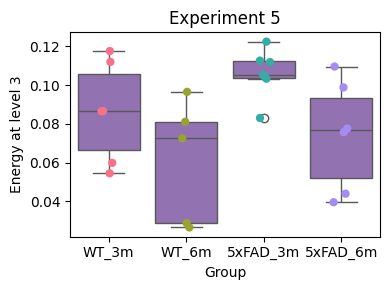

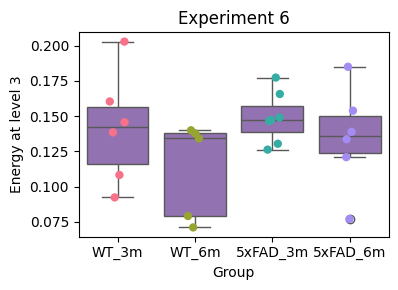

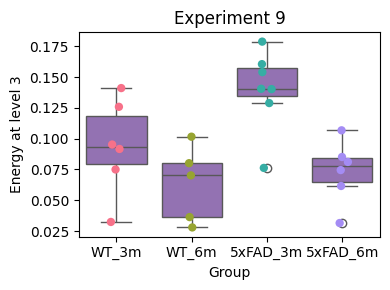

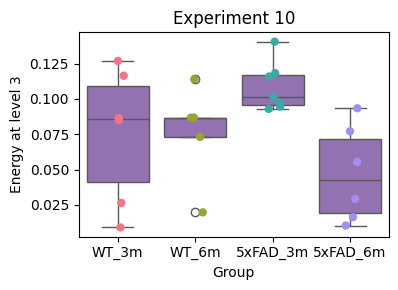

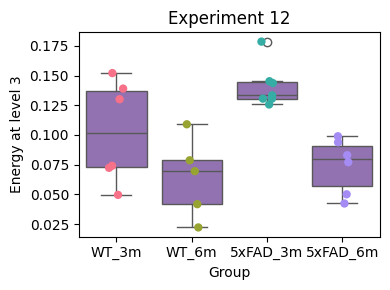

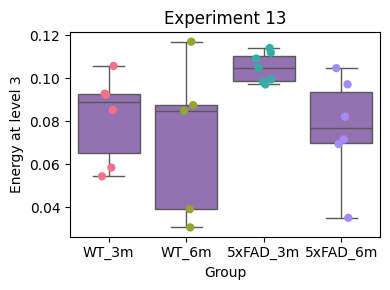

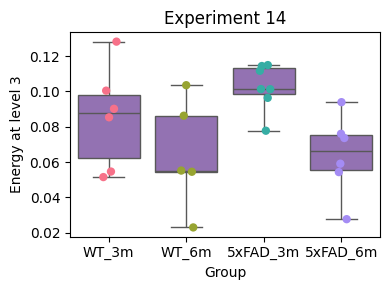

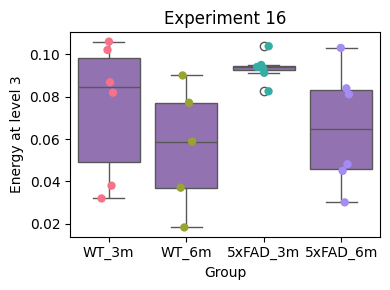

In [ ]:
for stimuli in [5,6,9,10,12,13,14,16]:
    plt.figure(figsize=(4,3))
    sns.stripplot(data=coactiv_stats[coactiv_stats['type']!='no class'], x='type', y=stimuli, jitter=True, size=6, palette='husl',hue='type')
    sns.boxplot(data=coactiv_stats[coactiv_stats['type']!='no class'], x='type', y=stimuli)
    plt.xlabel("Group")
    plt.ylabel("Energy at level 3")
    plt.title(f'Experiment {stimuli}')
    plt.tight_layout()
    plt.show()

## save data

In [10]:
wavelet_props = wavelet_props[wavelet_props['type'] != 'no class']
entropy_stats = entropy_stats[entropy_stats['type'] != 'no class']
kl_stats = kl_stats[kl_stats['type'] != 'no class']

In [14]:
### Save data for statistical comparisons

import json
# save
wavelet_props.to_json('Energy_level3.json')

In [18]:
entropy_stats.to_json('Entropy.json')
kl_stats.to_json('kl_div.json')
coactiv_stats.to_json('Coactiv.json')

In [17]:
import json
stimuli_list = [6,10,17,20]

# save
with open('Entropy.json', 'w') as f:
    json.dump(entropy_stats, f, indent=2)
with open('kl_div.json', 'w') as f:
    json.dump(kl_stats, f, indent=2)
with open('Coactiv.json', 'w') as f:
    json.dump(coactiv_stats, f, indent=2)

TypeError: Object of type DataFrame is not JSON serializable

In [26]:
import json
stimuli_list = [3,5,9,10,12,14,15,19,20]
groups       = ['WT_3m', 'WT_6m', '5xFAD_3m', '5xFAD_6m']

plot_data = {}

df_filtered = coactiv_stats[coactiv_stats['type'] != 'no class']

for stimuli in stimuli_list:
    plot_data[stimuli] = {}
    for group in groups:
        values = (
            df_filtered[df_filtered['type'] == group][stimuli]
            .dropna()
            .tolist()
        )
        plot_data[stimuli][group] = {
            'values':   values,           # raw points (what stripplot shows)
            'n':        len(values),       # sample size → goes into binomial_threshold
            'n_classes': len(groups),      # 4 groups → 4-class problem
        }

# save
with open('Coactiv.json', 'w') as f:
    json.dump(plot_data, f, indent=2)

## save classifiers

In [7]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(wavelet_props[i]).reshape(-1, 1), np.asarray(wavelet_props['type'].apply(age))) for i in range(21)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(wavelet_props[i]).reshape(-1, 1), np.asarray(wavelet_props['type'].apply(condition))) for i in range(21)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/energy_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/energy_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 46.15%
Most common params 0: {'svc__C': [100], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 42.31%
Most common params 1: {'svc__C': [100], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 50.00%
Most common params 2: {'svc__C': [1], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 61.54%
Most common params 3: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 46.15%
Most common params 4: {'svc__C': [1], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 73.08%
Most common params 5: {'svc__C': [10], 'svc__kernel': ['linear']}
Saved              5: models/svm_experiment_5.pkl

LOOCV Accuracy     6: 57.69%
Most commo

In [9]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(entropy_stats[i]).reshape(-1, 1), np.asarray(entropy_stats['type'].apply(age))) for i in range(21)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(entropy_stats[i]).reshape(-1, 1), np.asarray(entropy_stats['type'].apply(condition))) for i in range(21)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/entropy_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/entropy_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 42.31%
Most common params 0: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 50.00%
Most common params 1: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 65.38%
Most common params 2: {'svc__C': [1], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 57.69%
Most common params 3: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 65.38%
Most common params 4: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 69.23%
Most common params 5: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              5: models/svm_experiment_5.pkl

LOOCV Accuracy     6: 23.08%
Most common params 6: {'svc__C

In [10]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(kl_stats[i]).reshape(-1, 1), np.asarray(kl_stats['type'].apply(age))) for i in range(21)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(kl_stats[i]).reshape(-1, 1), np.asarray(kl_stats['type'].apply(condition))) for i in range(21)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/kldiv_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/kldiv_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 42.31%
Most common params 0: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 34.62%
Most common params 1: {'svc__C': [100], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 53.85%
Most common params 2: {'svc__C': [1], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 38.46%
Most common params 3: {'svc__C': [0.1], 'svc__degree': [3], 'svc__gamma': ['scale'], 'svc__kernel': ['poly']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 57.69%
Most common params 4: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 57.69%
Most common params 5: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              5: models/svm_experiment_5.pkl

LOOCV Accurac

In [11]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(coactiv_stats[i]).reshape(-1, 1), np.asarray(coactiv_stats['type'].apply(age))) for i in range(21)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(coactiv_stats[i]).reshape(-1, 1), np.asarray(coactiv_stats['type'].apply(condition))) for i in range(21)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/coactiv_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in range(21):
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/coactiv_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 58.33%
Most common params 0: {'svc__C': [10], 'svc__kernel': ['linear']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 62.50%
Most common params 1: {'svc__C': [10], 'svc__gamma': [0.1], 'svc__kernel': ['rbf']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 62.50%
Most common params 2: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 66.67%
Most common params 3: {'svc__C': [1], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 54.17%
Most common params 4: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 66.67%
Most common params 5: {'svc__C': [10], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              5: models/svm_experiment_5.pkl

LOOCV Accuracy     6: 45.83%
Most common params 6: {'svc__C': [1],